In [ ]:
from math import log10, sqrt

from scipy.integrate import solve_ivp
from scipy.constants import pi
import numpy as np

EPSILON_0_MEV_PER_FM3 = 150 # MeV/fm^3
MEV_PER_FM3_TO_SM_PER_KM_3 = 8.96498313e-7  # Conversion factor to convert from MeV/fm^3 to M☉/km^3
EPSILON_0 = EPSILON_0_MEV_PER_FM3 * MEV_PER_FM3_TO_SM_PER_KM_3  # M☉/km^3


@np.vectorize
def scale_mev_fm3_to_sm_km3(quantity: float) -> float:
    return quantity * MEV_PER_FM3_TO_SM_PER_KM_3


def gamma(point1: tuple[float, float], point2: tuple[float, float]):
    eps1, p1 = point1
    eps2, p2 = point2
    quantities = [eps1, eps2, p1, p2]
    [eps1, eps2, p1, p2] = scale_mev_fm3_to_sm_km3(quantities)
    return log10(p2 / p1) / log10(eps2 / eps1)


def kappa(point: tuple[float, float], gamma: float):
    eps, p = point
    p = p * MEV_PER_FM3_TO_SM_PER_KM_3
    eps = eps * MEV_PER_FM3_TO_SM_PER_KM_3
    return p / (eps**gamma)


def kappa_prime(kappa, gamma):
    return kappa * (EPSILON_0 ** (gamma - 1))


# Scaling to dimensionless
EOS_POINT_1 = (100, 1)  # (ε, P) in MeV/fm^3
EOS_POINT_2 = (180, 3)  # (ε, P) in MeV/fm^3
GAMMA = gamma(EOS_POINT_1, EOS_POINT_2) # Dimensionless
KAPPA = kappa(EOS_POINT_1, GAMMA)  # Units to cancel out epsilon^gamma where epsilon is in M☉/km^3.
KAPPA_PRIME = kappa_prime(KAPPA, GAMMA) # Dimensionless

# Scaling back to dimensional quantities
G_NU = 1.4766  # km/solar-mass
A = 1 / sqrt(G_NU * EPSILON_0) # Re-scaling constant
B = 1 / sqrt(G_NU**3 * EPSILON_0) # Re-scaling constant

def eos_epsilon(p_prime):
    return (p_prime / KAPPA_PRIME) ** (1 / GAMMA)

def mass_nu(m_prime):
    return B * m_prime


def radius_nu(r_prime):
    return A * r_prime


def tov_rhs(r, state):
    p, m = state
    if m <= 0:
        raise ValueError("r0 is too small")
    if p <= 0:
        return (0, 0)
    epsilon = eos_epsilon(p)
    f1 = -((m * epsilon) / r**2)
    f2 = 1 + (p / epsilon)
    f3 = 1 + (4 * pi * r**3 * p / m)
    f4 = 1 / (1 - (2 * m / r))
    dp_dr = f1 * f2 * f3 * f4
    dm_dr = (4 * pi) * r**2 * epsilon
    return (dp_dr, dm_dr)


def surface_event(r, state):
    p, _ = state
    return p


surface_event.terminal = True  # type: ignore
surface_event.direction = -1  # type: ignore


def solve_tov(p_c) -> tuple[float, float]:
    r_0 = 1e-5
    epsilon = eos_epsilon(p_c)
    m_0 = (4 * pi / 3) * r_0**3 * epsilon
    solutions = solve_ivp(
        tov_rhs,
        t_span=(r_0, 50),  # Should terminate before reaching endpoint.
        y0=(p_c, m_0),
        events=surface_event,
    )
    r_solutions = solutions.t
    m_solutions = solutions.y[1]
    return (max(r_solutions), max(m_solutions))


def test_single_p_c():
    p_c = 100 * MEV_PER_FM3_TO_SM_PER_KM_3
    p_prime = p_c / EPSILON_0
    r, m = solve_tov(p_prime)
    r = radius_nu(r)
    m = mass_nu(m)
    # For Pressure = 100 MeV/fm^3
    # Radius = 7.473417814092245 km
    # Mass = 0.5972517874652591 solar masses
    print(f"{r = } km | {m = } solar masses")


def generate_mass_radius_curve() -> tuple[list[float], list[float]]:
    pressure_range = np.logspace(0, 5, num=100)
    radii = []
    masses = []
    for p_c in pressure_range:
        # Convert central pressure to the correct units.
        p_c = p_c * MEV_PER_FM3_TO_SM_PER_KM_3
        p_prime = p_c / EPSILON_0
        r, m = solve_tov(p_prime)
        r = radius_nu(r)
        m = mass_nu(m)
        radii.append(r)
        masses.append(m)
    return (radii, masses)

def DEBUG():
    print(f"{GAMMA=}")
    print(f"{KAPPA=}")
    print(f"{KAPPA_PRIME=}")
    print(f"{G_NU=}")
    print(f"{A=}")
    print(f"{B=}")

# GAMMA = 2.0483159558007795
# KAPPA = 104.99248486360028
# KAPPA_PRIME = 0.009178052274417885
# G_NU = 1.4766
# A = 70.96565247024616
# B = 48.060173689723804
DEBUG()

GAMMA=1.869066370961403
KAPPA=32.92328321750623
KAPPA_PRIME=0.014224433899461477
G_NU=1.4766
A=70.96565247024616
B=48.060173689723804


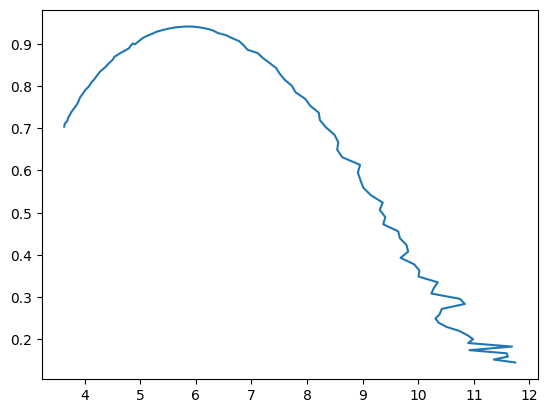

In [9]:
import matplotlib.pyplot as plt

radii, masses = generate_mass_radius_curve()

fig, ax = plt.subplots()
ax.plot(radii, masses)
plt.show()